# Model Performance Overview

**Feeds:** RQ1 (overall PT vs EN reliability). Also provides the span-level
F1 baseline that notebook 03 compares against for the span-vs-attribute
ceiling gap (RQ3).

Uses `results/test/{portuguese,english}/results.csv`, filtered to each
(model, language)'s best **(template, temperature)** configuration from
`best_configs.json` (notebook 01). The test stage did not run one template per
model at a fixed decoding setting -- it took each model's best template forward
and swept temperature -- so every number below is that model's argmax-F1
configuration, template *and* temperature, and the chosen temperature is
annotated on each bar.

Because the temperature is chosen on the test set, these are
best-configuration figures rather than held-out estimates; see notebook 01's
"Selecting the best (template, temperature) configuration" for the caveat.

In [1]:
import sys
sys.path.insert(0, ".")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import _common as c

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 100)


In [2]:
best_configs = c.load_best_configs()
test_results = pd.concat([c.load_results("test", lang) for lang in c.LANGUAGE_ORDER], ignore_index=True)
best_test = c.filter_to_best_configs(test_results, best_configs)

best_test[
    ["language", "model", "base_template", "temperature", "precision", "recall", "f1", "f1_r"]
].sort_values(["language", "model"]).reset_index(drop=True)

,language,model,base_template,temperature,precision,recall,f1,f1_r
0,english,amalia,cls_def_exp,0.3,0.173179,0.075581,0.105235,0.230098
1,english,euro_llm_9b,cls_exp,0.6,0.234821,0.203876,0.218257,0.478384
2,english,gemini,ext_def_exp,0.6,0.556624,0.493411,0.523115,0.788913
3,english,gemma3_12b,cls_exp,0.6,0.405844,0.339147,0.369510,0.691615
4,english,gemma3_4b,cls_def_exp,0.3,0.342449,0.223256,0.270296,0.657475
5,english,gervasio_8b_ptpt,ext_def_exp,0.3,0.384580,0.322868,0.351032,0.698049
6,english,qwen3_14b,ext_exp,1.0,0.393956,0.277907,0.325909,0.744467
7,english,qwen3_4b,cls_def_exp,0.6,0.299604,0.263953,0.280651,0.620468
8,english,qwen3_8b,ext_exp,1.0,0.384852,0.242248,0.297336,0.754903
9,portuguese,amalia,cls_def_exp,0.3,0.213989,0.139922,0.169206,0.429669


### Which configuration was selected, and out of how many

`template_source` flags the four (model, language) pairs whose test stage was
never run with the template that prompt selection favoured, so the selection
fell back to the template actually run (see notebook 01). `n_candidates` is how
many temperature settings the argmax ranged over -- 1 means the model has a
single recorded test run, so its "best temperature" is not a choice at all and
should not be read as evidence about temperature.

In [3]:
c.best_configs_frame(best_configs)[
    ["language", "model", "base_template", "temperature", "n_candidates", "template_source", "f1", "f1_r"]
]

,language,model,base_template,temperature,n_candidates,template_source,f1,f1_r
0,english,amalia,cls_def_exp,0.3,1,prompt_selection,0.105235,0.230098
1,english,euro_llm_9b,cls_exp,0.6,3,test_stage_fallback,0.218257,0.478384
2,english,gemini,ext_def_exp,0.6,3,prompt_selection,0.523115,0.788913
3,english,gemma3_12b,cls_exp,0.6,3,prompt_selection,0.369510,0.691615
4,english,gemma3_4b,cls_def_exp,0.3,3,prompt_selection,0.270296,0.657475
5,english,gervasio_8b_ptpt,ext_def_exp,0.3,3,prompt_selection,0.351032,0.698049
6,english,qwen3_14b,ext_exp,1.0,3,prompt_selection,0.325909,0.744467
7,english,qwen3_4b,cls_def_exp,0.6,3,test_stage_fallback,0.280651,0.620468
8,english,qwen3_8b,ext_exp,1.0,3,test_stage_fallback,0.297336,0.754903
9,portuguese,amalia,cls_def_exp,0.3,1,prompt_selection,0.169206,0.429669


## F1 and F1-r leaderboard, by model and language

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\best-template-temperature\report\Figures\results\02_f1_leaderboard.pdf


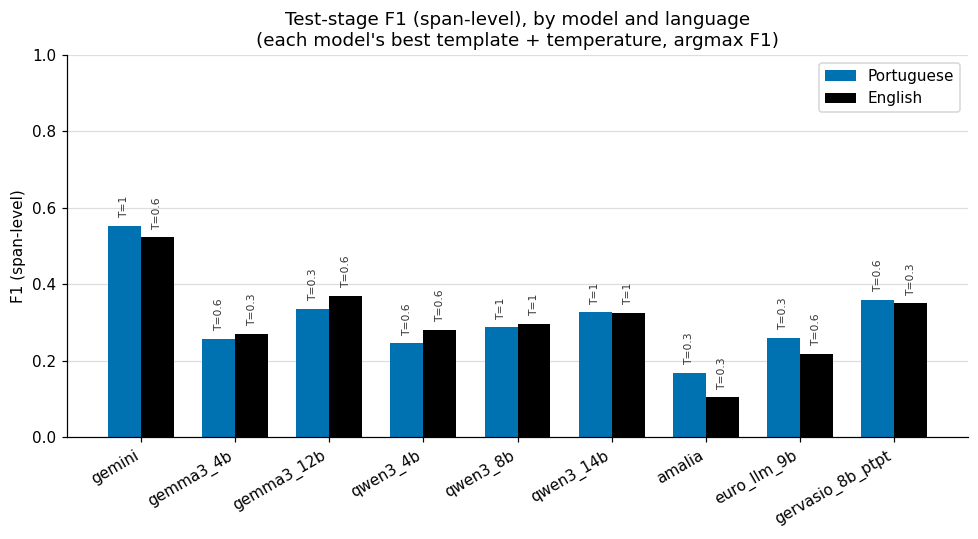

In [4]:
def plot_leaderboard(metric, ylabel, fname):
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(c.MODEL_ORDER))
    width = 0.35
    for i, lang in enumerate(c.LANGUAGE_ORDER):
        sub = best_test[best_test["language"] == lang].set_index("model").reindex(c.MODEL_ORDER)
        offset = (i - 0.5) * width
        ax.bar(x + offset, sub[metric].values, width=width, color=c.LANGUAGE_COLORS[lang], label=lang.capitalize())
        # Each bar is a different decoding temperature (each model's own best),
        # so label it -- otherwise the chart reads as a single controlled
        # setting across models, which it is not.
        for xi, value, temp in zip(x + offset, sub[metric].values, sub["temperature"].values):
            if np.isnan(value):
                continue
            ax.text(xi, value + 0.02, f"T={temp:g}", ha="center", va="bottom",
                    fontsize=7, rotation=90, color="#333333")
    ax.set_xticks(x)
    ax.set_xticklabels(c.MODEL_ORDER, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1)
    ax.set_title(f"Test-stage {ylabel}, by model and language\n(each model's best template + temperature, argmax F1)")
    ax.legend()
    c.style_axis(ax)
    c.save_fig(fig, fname)
    plt.show()


plot_leaderboard("f1", "F1 (span-level)", "02_f1_leaderboard")

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\best-template-temperature\report\Figures\results\02_f1r_leaderboard.pdf


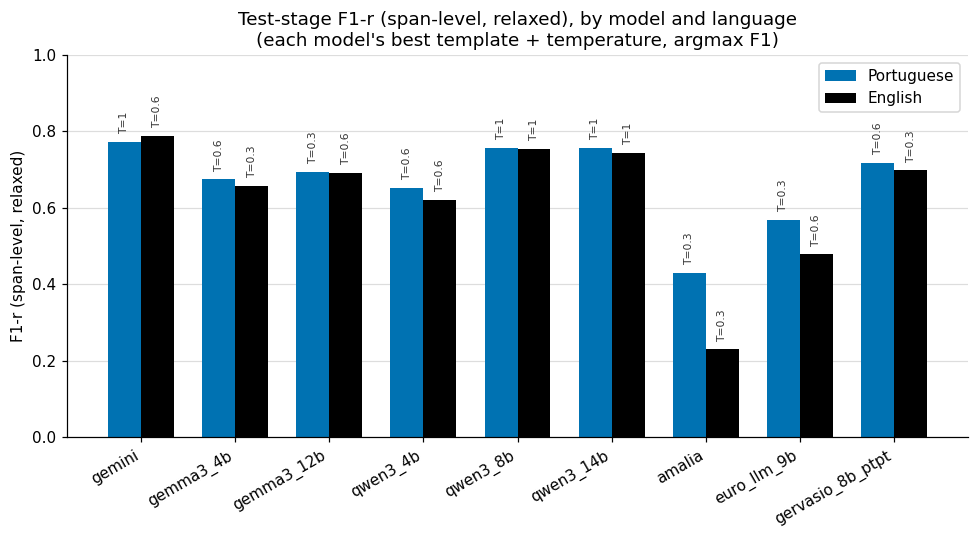

In [5]:
plot_leaderboard("f1_r", "F1-r (span-level, relaxed)", "02_f1r_leaderboard")

## Synthesis

- Feeds **RQ1**: overall test-stage reliability per model, PT vs EN, using each model's own best
  prompt template *and* best decoding temperature (`best_configs.json`, notebook 01).
- The configuration is not constant across bars: the argmax-F1 temperature differs by model and
  by language, which is why each bar carries its own `T=` label. Read the chart as "best
  achievable per model", not as a controlled comparison at a fixed decoding setting.
- Since the temperature is selected on the test set, these F1 values are optimistic as
  generalisation estimates. Notebook 01's temperature sweep bounds the optimism: a few F1 points
  within a model, well below the template effect.
- Four (model, language) pairs fall back to the template actually run in the test stage rather
  than the prompt-selection argmax (`template_source == "test_stage_fallback"`); `amalia` has a
  single recorded run in each language, so its temperature is not a selection.
- `llama32_3b` is excluded throughout (see notebook 01's note and `_common.EXCLUDED_MODELS`) --
  its results are invalid, not merely missing.
- Missing bars otherwise indicate a (model, language) combination with no test-stage run.
- This span-level F1 is the baseline notebook 03 subtracts the attribute-level (type-aware) F1
  from, to quantify the span-vs-attribute ceiling gap for RQ3 -- both notebooks now read the same
  runs, so the subtraction is like-for-like.